# 450 — Predefined time-frequency ROI pooling (i.e. quantifying known things in known places)

The **cluster-blind, condition-blind** pooling path. A fixed, physiology-driven library of
time-frequency **ROIs** (`functions/roi_config.py`) is applied to **every** electrode × condition
ERSP — independent of the 02 clusters and of audio/picture/reading. Each ROI is a 2-D box
(`f_rows × t_bins`, 1-based inclusive) + a **sign** hypothesis, encoding a documented marker
(sensory-onset HGA, sustained processing, pre-response planning, motor execution, alpha/beta ERD,
theta retrieval, …). Pooling turns each ERSP into a small citation-anchored feature vector.

- **Pool** = mean dB in the box. **Qualify** = the box clears the clustering σ/proportion gate in
  the ROI's **own sign** (`pos`/`neg`/`both`).
- **Option A aggregation:** a contact **expresses** an ROI if it qualifies in **≥1 condition**.
- This is **additive** — the zone-based `410–490` path is untouched.

> ⚠️ Two predeterminant issues to reconcile (see the validation table in §1): the **ds vs full**
> Hz ranges disagree for `alpha_beta_suppression` and `broadband_activation_index`; and the
> `broadband_activation_index` box-mean is **not** Manning's broadband index (a slope/offset
> measure) — treat it cautiously or redefine it.


In [1]:
import os, sys
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import display, Markdown, Image
sys.path.insert(0, str(Path('..').resolve()))
from functions import lf_pool as P

INPUT_DIR = Path(r'\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY')
if not INPUT_DIR.exists():
    INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY').resolve()

print('INPUT_DIR :', INPUT_DIR, '| exists:', INPUT_DIR.exists())
print('OUTPUTS   :', P.OUTPUTS_ROOT)
print('COORDS    :', P.COORDS_DIR, '| exists:', P.COORDS_DIR.exists())
print('conditions:', P.CONDITIONS, '| zones:', P.DEFAULT_ZONES)
print('feature sets:', P.FEATURE_SETS, '| window shapes:', P.WINDOW_SHAPES)


INPUT_DIR : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY | exists: True
OUTPUTS   : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling
COORDS    : \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\outputs\250_recon\fsaverage\coords | exists: True
conditions: ('audio', 'picture', 'reading') | zones: ('perception', 'pre_articulation', 'audio')
feature sets: ('hg', 'bands15') | window shapes: ('boxcar', 'gaussian')


In [2]:
# ---- knobs ----
USE_DS       = True                  # True: 15x30 ds grid · False: full 129x300
GRID         = 'ds' if USE_DS else 'full'
DS_TIME_BINS = 30
print('grid:', GRID, '| n ROIs:', len(P.ROI_PARAMS[GRID]))


grid: ds | n ROIs: 11


## 1 — The ROI map (with legend) + consistency check
Each box labelled `(a) (b) (c) …`, coloured red = positive / blue = negative / purple = both.
Same-box opposite-sign ROIs overlap, so positive and negative signs are also drawn separately.
The validation table flags any ds↔full Hz / sign mismatches.


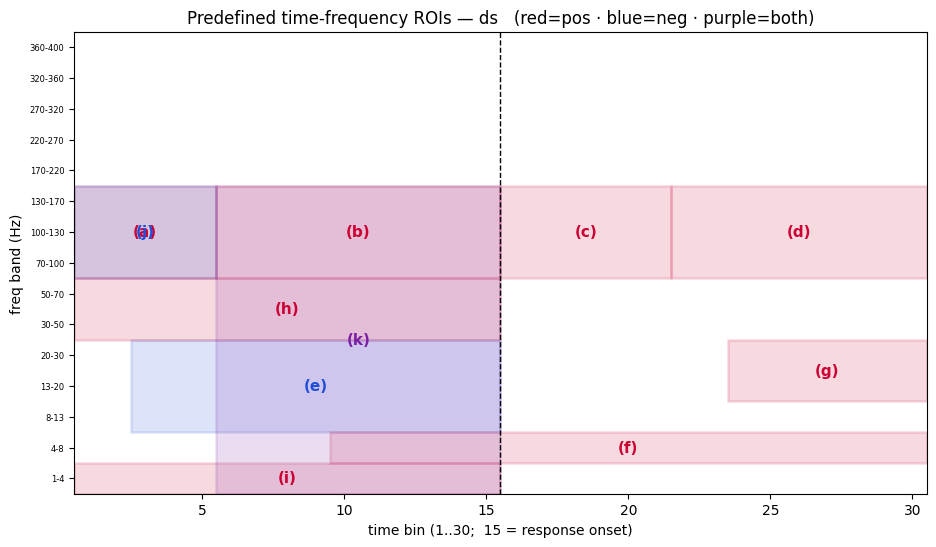

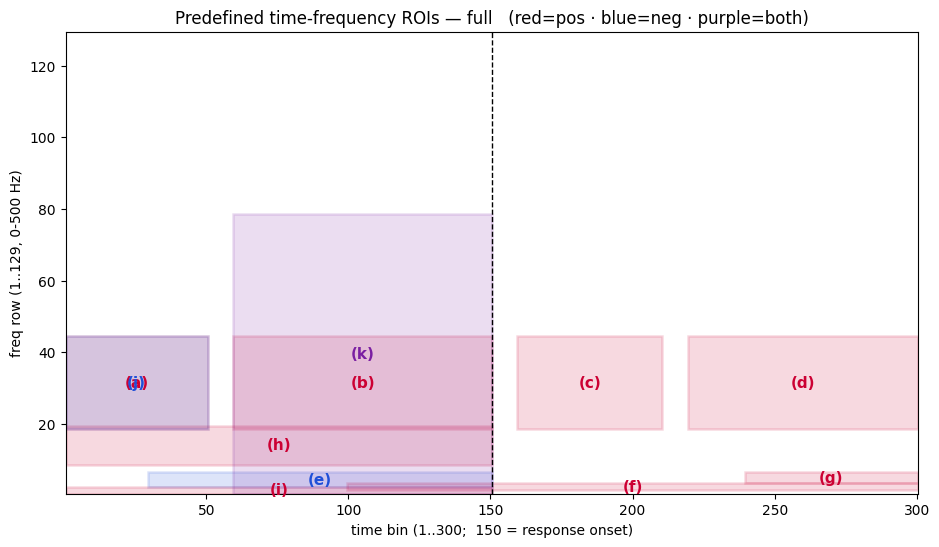

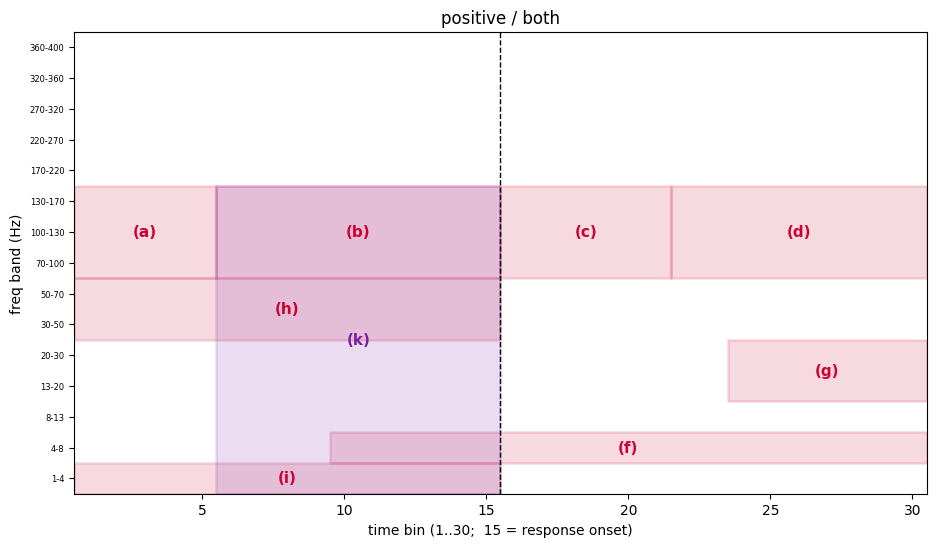

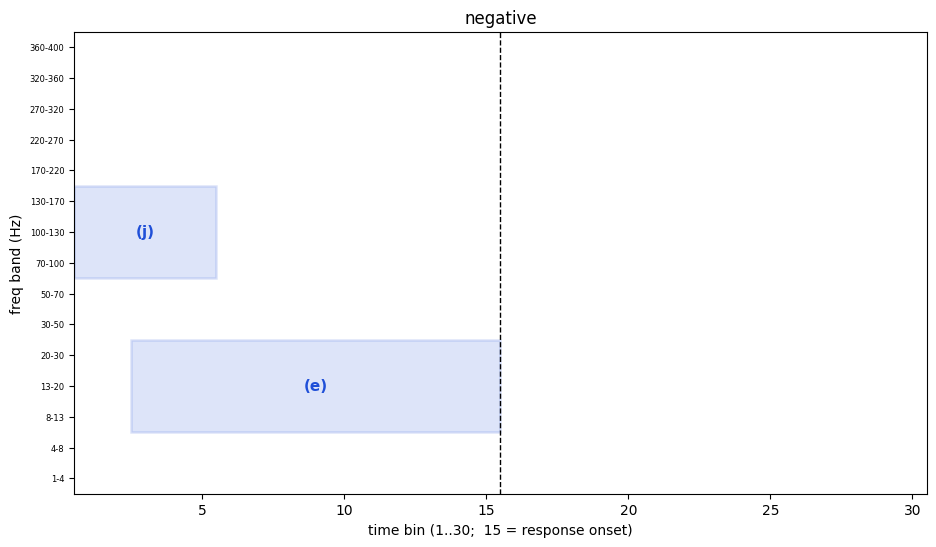

,tag,label,sign,t_bins,f_rows,description
0,(a),early_sensory_onset,pos,"(1, 5)","(8, 10)",Initial cortical response to stimulus onset (a...
1,(b),sustained_stimulus_processing,pos,"(6, 15)","(8, 10)",Sustained HGA during stimulus comprehension an...
2,(c),pre_response_planning,pos,"(16, 21)","(8, 10)",Internal response formulation window prior to ...
3,(d),motor_execution,pos,"(22, 30)","(8, 10)",Articulation and mouth movement during overt r...
4,(e),alpha_beta_suppression,neg,"(3, 15)","(3, 5)",ERD in alpha and beta during cortical engageme...
5,(f),theta_retrieval,pos,"(10, 30)","(2, 2)",Theta increase spanning late stimulus through ...
6,(g),post_response_beta_rebound,pos,"(24, 30)","(4, 5)",Beta power increase after motor response - cor...
7,(h),narrowband_gamma_stimulus,pos,"(1, 15)","(6, 7)",Narrowband gamma during stimulus - distinct ge...
8,(i),sustained_delta_engagement,pos,"(1, 15)","(1, 1)",Sustained low-frequency increase across full s...
9,(j),early_hga_suppression,neg,"(1, 5)","(8, 10)",HGA attenuation at stimulus onset - prefrontal...



ds <-> full consistency (hz_mismatch / sign_mismatch = reconcile):


,label,ds_hz,ds_t_pct,ds_sign,full_hz,full_t_pct,full_sign,hz_mismatch,sign_mismatch
0,early_sensory_onset,"(70.0, 170.0)","(0, 17)",pos,"(70, 168)","(0, 17)",pos,False,False
1,sustained_stimulus_processing,"(70.0, 170.0)","(17, 50)",pos,"(70, 168)","(20, 50)",pos,False,False
2,pre_response_planning,"(70.0, 170.0)","(50, 70)",pos,"(70, 168)","(53, 70)",pos,False,False
3,motor_execution,"(70.0, 170.0)","(70, 100)",pos,"(70, 168)","(73, 100)",pos,False,False
4,alpha_beta_suppression,"(8.0, 30.0)","(7, 50)",neg,"(8, 20)","(10, 50)",neg,True,False
5,theta_retrieval,"(4.0, 8.0)","(30, 100)",pos,"(4, 8)","(33, 100)",pos,False,False
6,post_response_beta_rebound,"(13.0, 30.0)","(77, 100)",pos,"(12, 20)","(80, 100)",pos,True,False
7,narrowband_gamma_stimulus,"(30.0, 70.0)","(0, 50)",pos,"(31, 70)","(0, 50)",pos,False,False
8,sustained_delta_engagement,"(1.0, 4.0)","(0, 50)",pos,"(0, 4)","(0, 50)",pos,False,False
9,early_hga_suppression,"(70.0, 170.0)","(0, 17)",neg,"(70, 168)","(0, 17)",neg,False,False


In [3]:
import matplotlib.pyplot as plt
disc = P.new_run_dir('roi', GRID + '_map')
for g in ('ds', 'full'):
    P.plot_roi_map(grid=g, out_png=disc / f'roi_map_{g}.png'); plt.show()
# pos / neg separated (so the early-onset vs early-suppression twins don't overlap)
P.plot_roi_map(grid=GRID, signs=('pos', 'both')); plt.title('positive / both'); plt.show()
P.plot_roi_map(grid=GRID, signs=('neg',));         plt.title('negative');       plt.show()
display(P.roi_legend(grid=GRID))
print('\nds <-> full consistency (hz_mismatch / sign_mismatch = reconcile):')
display(P.validate_roi_config())


## 2 — Pool every contact against every ROI
Condition-blind: one row per (contact, condition, ROI). Cached to
`outputs/_dataset/pooling/roi_table_<grid>.parquet`.


In [4]:
df_meta, X_full = P.prepare_pooling_dataset(INPUT_DIR)
X = P.downsample_dataset(X_full, time_bins=DS_TIME_BINS) if USE_DS else X_full
df_roi = P.build_roi_table(df_meta, X, grid=GRID)
print('roi table:', df_roi.shape)
df_roi.head()


[lf_dataset cache hit] \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\_dataset\pooling\_raw_ungated
  8841 samples · X_3d.shape=(8841, 129, 300)
[lf_pool] 8841 samples, 8841 with a contact key, X_3d=(8841, 129, 300)
[build_X_3d_downsampled] 8841 samples · 15 freq bins · 30 time bins · flat dim = 450
[lf_pool] roi run -> \\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\04_FBM_Pooling\outputs\pooling\roi\ds\runs\20260612_161553
[lf_pool] roi table: (97251, 16)  (11 ROIs x 8841 samples)
roi table: (97251, 16)


,patient_id,electrode,contact_norm,condition,grid,roi_tag,roi_label,sign,f_lo_row,f_hi_row,t_lo_bin,t_hi_bin,pooled_db,prop_pos,prop_neg,qualifies
0,EL030,A_L10,AL10,audio,ds,(a),early_sensory_onset,pos,8,10,1,5,-0.816537,0.000000,0.0,False
1,EL030,A_L10,AL10,audio,ds,(b),sustained_stimulus_processing,pos,8,10,6,15,-1.135040,0.000000,0.0,False
2,EL030,A_L10,AL10,audio,ds,(c),pre_response_planning,pos,8,10,16,21,0.512875,0.000000,0.0,False
3,EL030,A_L10,AL10,audio,ds,(d),motor_execution,pos,8,10,22,30,1.648952,0.185185,0.0,True
4,EL030,A_L10,AL10,audio,ds,(e),alpha_beta_suppression,neg,3,5,3,15,0.423254,0.000000,0.0,False


## 3 — Per-ROI qualifier counts (option A)
Distinct contacts expressing each ROI in ≥1 condition.


,roi_tag,roi_label,sign,n_contacts
0,(a),early_sensory_onset,pos,151
1,(b),sustained_stimulus_processing,pos,134
2,(c),pre_response_planning,pos,329
3,(d),motor_execution,pos,501
4,(e),alpha_beta_suppression,neg,411
5,(f),theta_retrieval,pos,1138
6,(g),post_response_beta_rebound,pos,106
7,(h),narrowband_gamma_stimulus,pos,218
8,(i),sustained_delta_engagement,pos,1696
9,(j),early_hga_suppression,neg,1


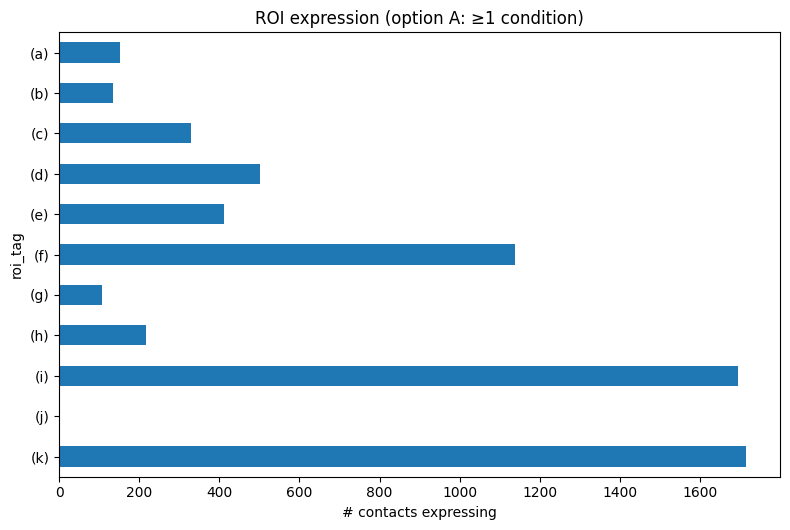

In [5]:
counts = P.roi_counts(df_roi)
display(counts)
ax = counts.set_index('roi_tag')['n_contacts'].plot.barh(
    figsize=(8, 0.4 * len(counts) + 1))
ax.set_xlabel('# contacts expressing'); ax.set_title('ROI expression (option A: ≥1 condition)')
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 4 — Where do they map? (ROI × Yeo-7)
Crosstab of expressing contacts by anatomical network — the condition-blind "where each signature
lives" map. (Yeo from the coords CSVs; no MNE needed.)


In [6]:
coords = P.load_coords()
ct = P.roi_region_crosstab(df_roi, coords, scheme='yeo7')
display(ct)


region,7Networks_1,7Networks_2,7Networks_3,7Networks_4,7Networks_5,7Networks_6,7Networks_7
roi,,,,,,,
(a) early_sensory_onset,23,55,4,8,14,7,21
(b) sustained_stimulus_processing,22,38,1,7,12,11,28
(c) pre_response_planning,13,80,14,27,37,25,76
(d) motor_execution,18,126,17,36,59,32,151
(e) alpha_beta_suppression,23,45,53,66,37,62,95
(f) theta_retrieval,35,135,40,61,149,105,365
(g) post_response_beta_rebound,4,14,3,11,9,9,31
(h) narrowband_gamma_stimulus,19,33,6,9,38,21,44
(i) sustained_delta_engagement,57,171,78,120,216,210,501
